# GGPlots

In [2]:
require(tidyverse)

In [11]:
#data()

In [12]:
#data(cms_patient_care)

In [13]:
#cms_patient_care

In [14]:
nhanes <- read_csv("data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Lengt...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


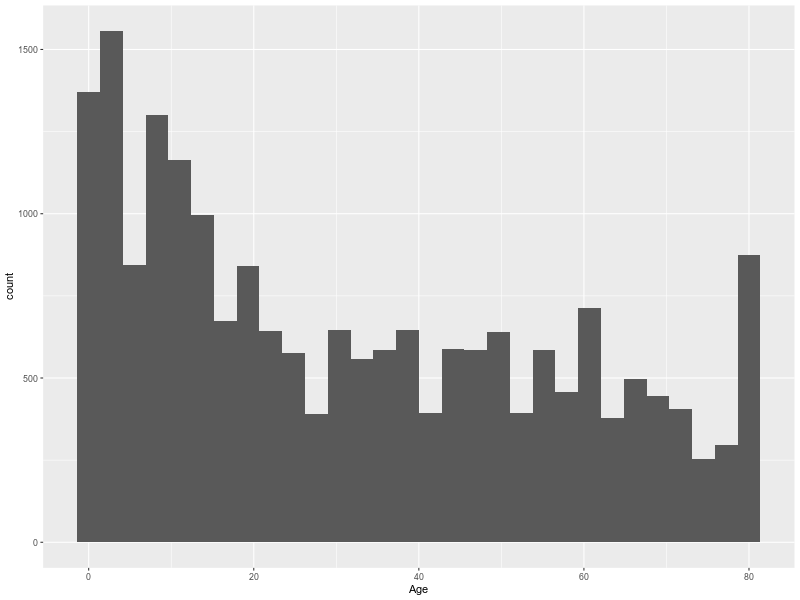

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

In [ ]:
#Basics -> GGplot creates canvas + 
# aesthetics prepares the canvas to overlay data + 
# geometry for the plot shape
nhanes |> ggplot() + aes(Age) + geom_histogram()

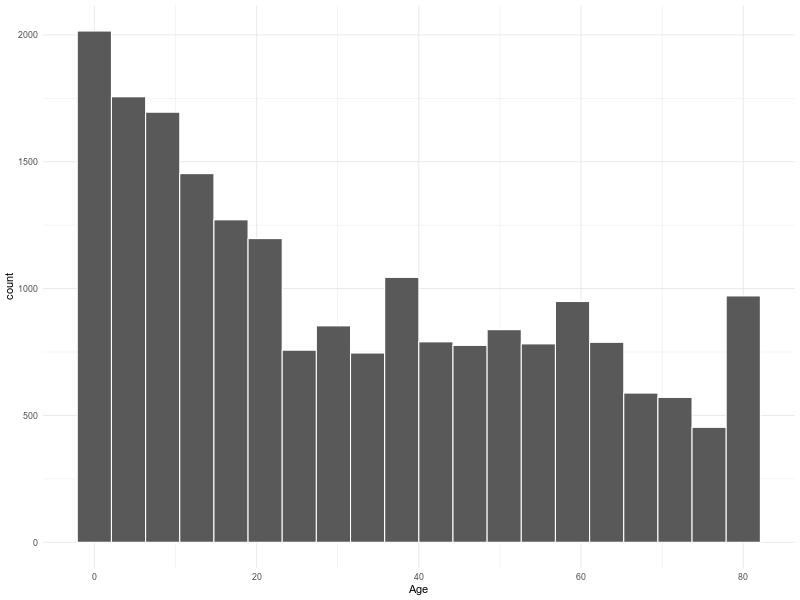

In [30]:
#Numeric Vatiables Single
nhanes |> 
  ggplot() + 
  aes(Age) + 
  geom_histogram(color='white', bins=20) + 
  theme_minimal()

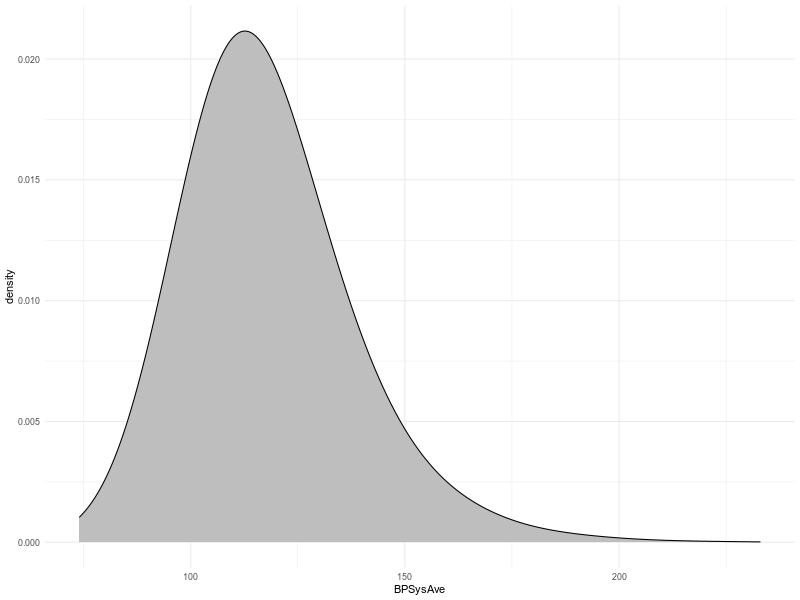

In [49]:
nhanes |> 
  filter(!is.na(BPSysAve)) |> 
  ggplot() + 
  aes(BPSysAve) + 
  geom_density(bw=10, fill='grey') + 
  theme_minimal()

In [37]:
nhanes |> select(BPSysAve) |> filter(!is.na(BPSysAve))

# A tibble: 14,867 × 1
   BPSysAve
      <dbl>
 1      113
 2      109
 3       93
 4      150
 5      104
 6      112
 7      108
 8      139
 9       94
10      121
# ℹ 14,857 more rows
# ℹ Use `print(n = ...)` to see more rows

In [50]:
!T

[1] FALSE

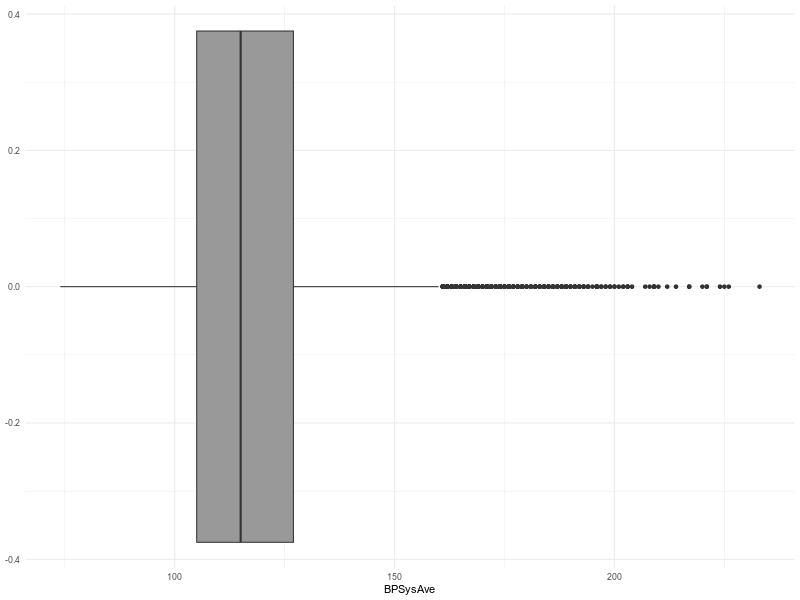

In [53]:
nhanes |> 
  filter(!is.na(BPSysAve)) |> 
  ggplot() + 
  aes(BPSysAve) + 
  geom_boxplot(fill='#999') + 
  theme_minimal()

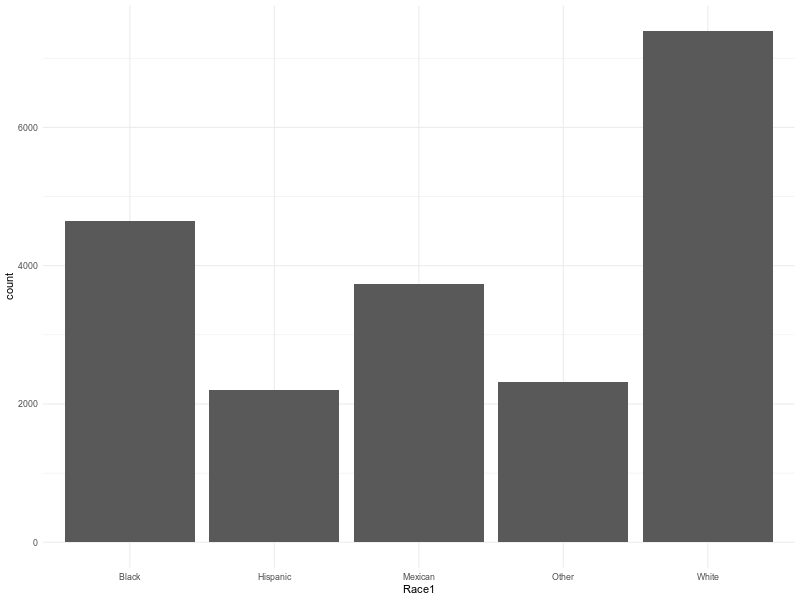

In [56]:
# Categorical variables single
nhanes |> 
  ggplot() + 
  aes(Race1) + 
  geom_bar() + 
  theme_minimal()

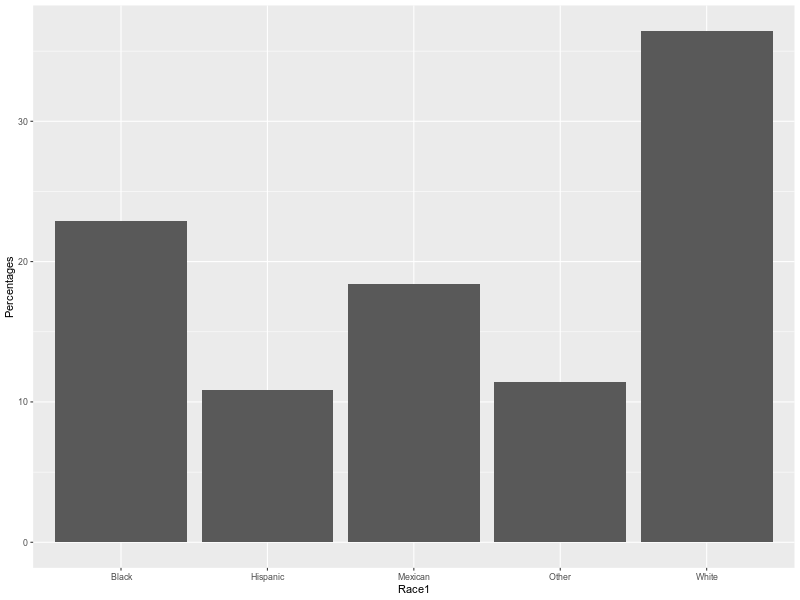

In [68]:
nhanes |> 
  group_by(Race1) |> 
  summarize(
    Frequencies = n(), 
    Proportions = n()/nrow(nhanes), 
    Percentages = (n()/nrow(nhanes)) * 100
  ) |> 
  ggplot() + 
  aes(x=Race1, y=Percentages) + 
  geom_col()

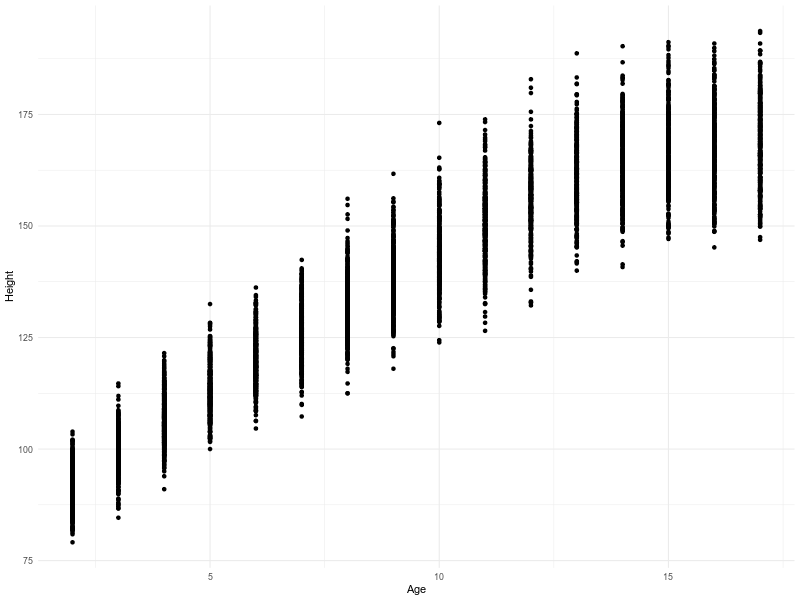

In [76]:
# Comparing 2 variables - Num vs Num
nhanes |> 
  filter(!is.na(Age) & !is.na(Height)) |> # removed any missings for age and height
  filter(Age < 18) |> # restricting to children only
  ggplot() + 
  aes(x=Age, y=Height) + 
  geom_point() + 
  theme_minimal()

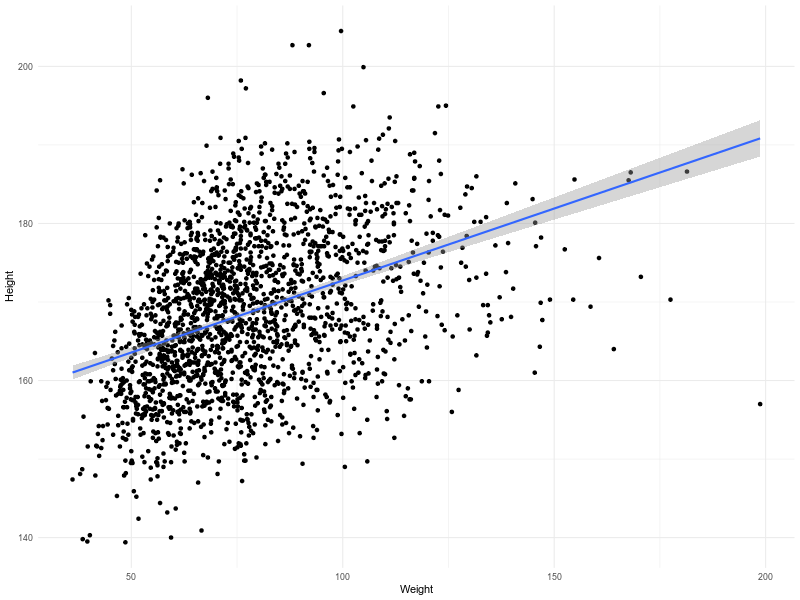

`geom_smooth()` using formula = 'y ~ x'

In [86]:
nhanes |> 
  filter(!is.na(Weight) & !is.na(Height)) |>
  filter(Age |> between(20, 29)) |>
  ggplot() + 
  aes(Weight, Height) + 
  geom_point() + 
  geom_smooth(method=lm) +
  theme_minimal()

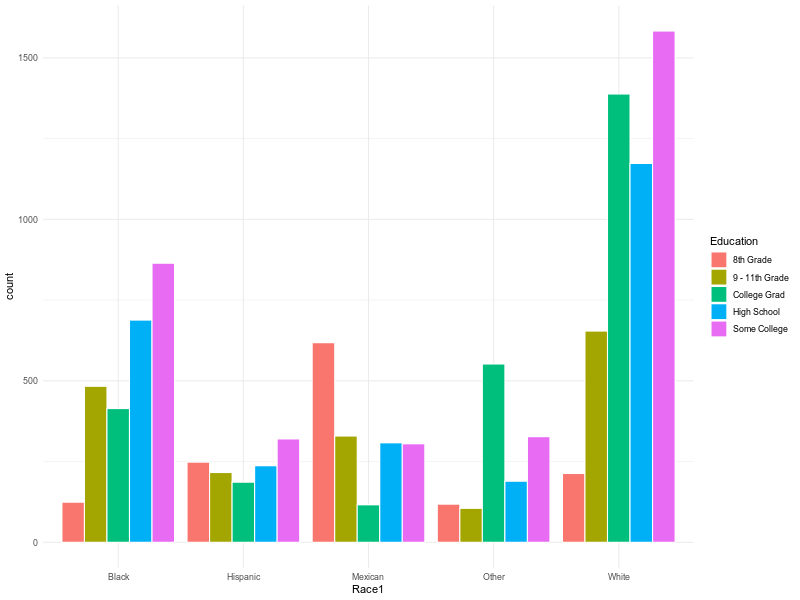

In [100]:
# cat vs cat
nhanes |> 
  filter(!is.na(Education)) |> 
  ggplot() + 
  aes(Race1, fill=Education) + 
  geom_bar(position='dodge', color='white') + 
  theme_minimal()


In [116]:
nhanes |> 
  filter(!is.na(Education)) |> 
  group_by(Race1, Education) |> 
  summarize(
    Frequency = n(), 
    Proportion = n()/nrow(nhanes),
    Percentage = (n()/nrow(nhanes)) * 100,
    #.groups = 'rowwise'
  ) 

`summarise()` has grouped output by 'Race1'. You can override using the
`.groups` argument.


# A tibble: 25 × 5
# Groups:   Race1 [5]
   Race1    Education      Frequency Proportion Percentage
   <chr>    <chr>              <int>      <dbl>      <dbl>
 1 Black    8th Grade            124    0.00611      0.611
 2 Black    9 - 11th Grade       483    0.0238       2.38 
 3 Black    College Grad         414    0.0204       2.04 
 4 Black    High School          688    0.0339       3.39 
 5 Black    Some College         864    0.0426       4.26 
 6 Hispanic 8th Grade            248    0.0122       1.22 
 7 Hispanic 9 - 11th Grade       216    0.0106       1.06 
 8 Hispanic College Grad         186    0.00917      0.917
 9 Hispanic High School          237    0.0117       1.17 
10 Hispanic Some College         320    0.0158       1.58 
# ℹ 15 more rows
# ℹ Use `print(n = ...)` to see more rows

In [126]:
#

In [110]:
nhanes |> 
  select(Race1, Education) |> 
  table() |> 
  prop.table(2)

          Education
Race1       8th Grade 9 - 11th Grade College Grad High School Some College
  Black    0.09386828     0.27028539   0.15587349  0.26512524   0.25419241
  Hispanic 0.18773656     0.12087297   0.07003012  0.09132948   0.09414534
  Mexican  0.46782740     0.18410744   0.04367470  0.11868979   0.08973227
  Other    0.08932627     0.05875769   0.20783133  0.07283237   0.09620477
  White    0.16124148     0.36597650   0.52259036  0.45202312   0.46572521

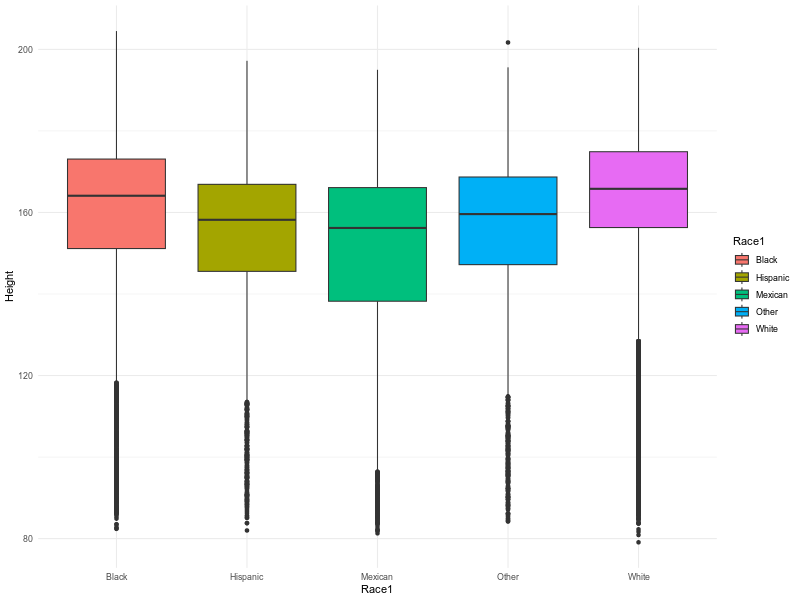

In [133]:
# Num vs Cat
nhanes |> 
  filter(!is.na(Height)) |>
  ggplot() + 
  aes(Race1, Height, fill=Race1) + 
  geom_boxplot() + 
  theme_minimal()